In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [49]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [50]:
df = pd.read_csv('data/Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# **Data Description**

- **country**: Name of the country.
- **child_mort**: Death of children under 5 years of age per 1000 live births.
- **exports**: Exports of goods and services per capita. Given as %age of the GDP per capita.
- **health**: Total health spending per capita. Given as %age of GDP per capita.
- **imports**: Imports of goods and services per capita. Given as %age of the GDP per capita.
- **income**: Net income per person.
- **inflation**: The measurement of the annual growth rate of the Total GDP.
- **life_expec**: The average number of years a new born child would live if the current mortality patterns are to remain the same.
- **total_fer**: The number of children that would be born to each woman if the current age-fertility rates remain the same.
- **gdpp**: The GDP per capita. Calculated as the Total GDP divided by the total population.

In [51]:
df.shape

(167, 10)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [53]:
df.duplicated().sum()

0

In [54]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


# **Data Visualisation**

### **a) Income**

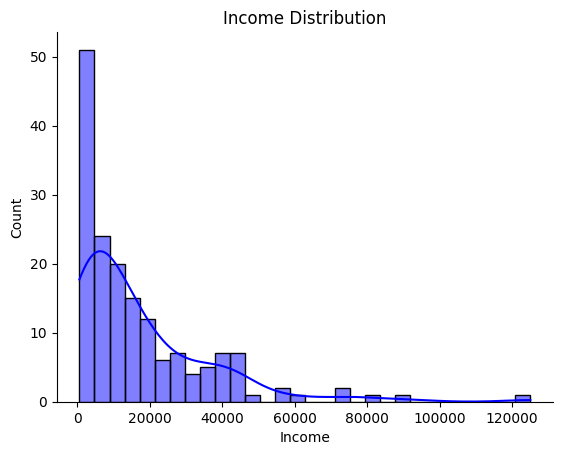

In [55]:
sns.histplot(data=df, x='income', kde=True, bins=30, color='blue')
plt.title('Income Distribution')
plt.xlabel('Income')
sns.despine()
plt.show()

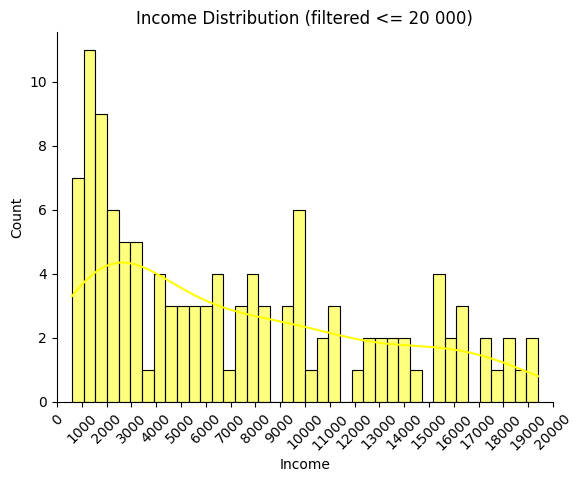

In [56]:
df_filtered = df[df['income'] <= 20000]

sns.histplot(data=df_filtered, x='income', kde=True, bins=40, color='yellow')
plt.title('Income Distribution (filtered <= 20 000)')
plt.xlabel('Income')
plt.xticks(range(0,21000,1000), rotation=45)
plt.xlim(0,20000)
sns.despine()
plt.show()

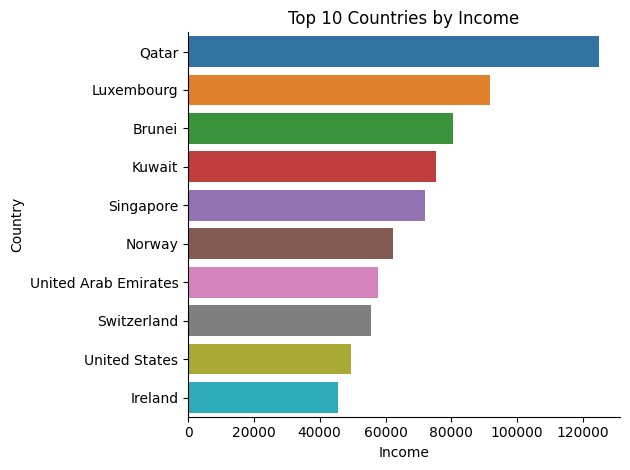

In [77]:
top_countries = df.sort_values(by='income', ascending=False).head(10)

sns.barplot(data=top_countries, y='country', x='income', ci=None, palette=sns.color_palette('tab10', n_colors=10))
plt.title('Top 10 Countries by Income')
plt.ylabel('Country')
plt.xlabel('Income')
plt.tight_layout()
sns.despine()
plt.show()

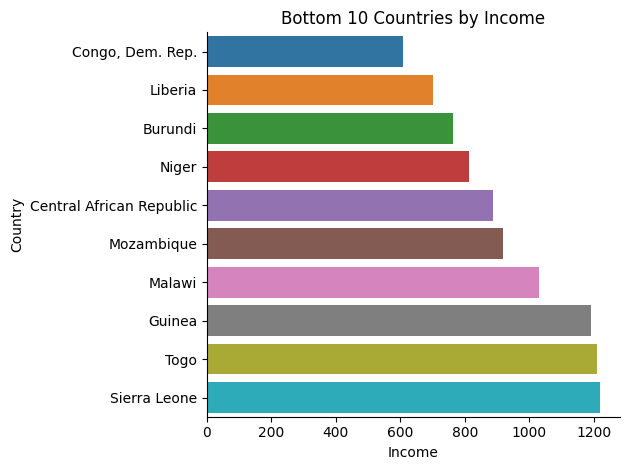

In [79]:
bottom10 = df.sort_values(by='income', ascending=True).head(10)

sns.barplot(data=bottom10, x='income', y='country', ci=None, palette=sns.color_palette('tab10', n_colors=10))
plt.title('Bottom 10 Countries by Income')
plt.xlabel('Income')
plt.ylabel('Country')
plt.tight_layout()
sns.despine()
plt.show()

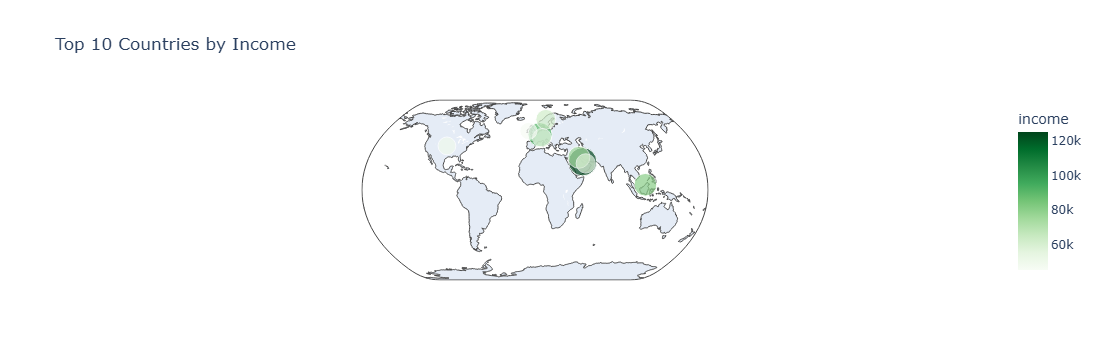

In [59]:
import plotly.express as px

top10 = df.nlargest(10, 'income')
fig = px.scatter_geo(top10, locations='country', locationmode='country names',
                     size='income', color='income', color_continuous_scale='Greens',
                     hover_name='country',
                     projection='natural earth', title='Top 10 Countries by Income')
fig.show()

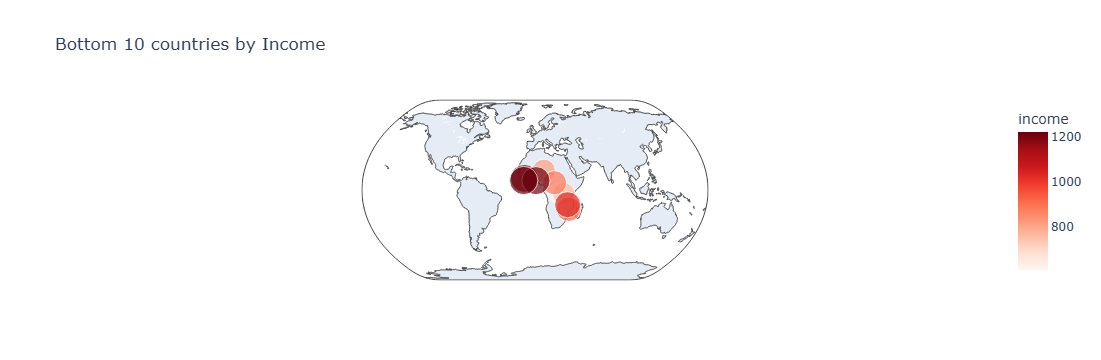

In [61]:
bottom10 = df.nsmallest(10, 'income')

fig= px.scatter_geo(bottom10, locations='country', locationmode='country names',
                    size='income', color='income', color_continuous_scale='Reds',
                    hover_name='country', projection='natural earth', title='Bottom 10 countries by Income')
fig.show()

### **b) Life Expectancy**

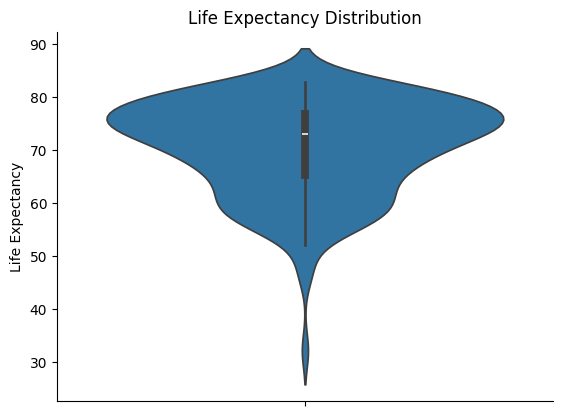

In [68]:
sns.violinplot(data=df, y='life_expec')
plt.title('Life Expectancy Distribution')
plt.ylabel('Life Expectancy')
sns.despine()
plt.show()

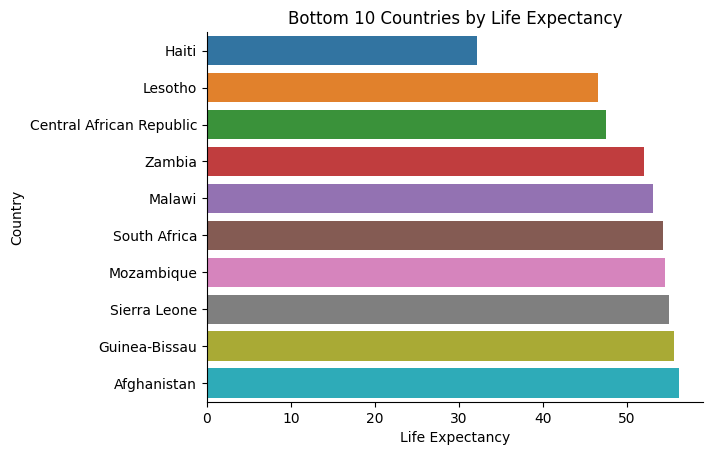

In [75]:
bottom10 = df.sort_values(by='life_expec', ascending=True).head(10)

sns.barplot(data=bottom10, x='life_expec', y='country', ci=None, palette=sns.color_palette('tab10', n_colors=10))
plt.title('Bottom 10 Countries by Life Expectancy')
plt.xlabel('Life Expectancy')
plt.ylabel('Country')
sns.despine()
plt.show()

### **c) Health**

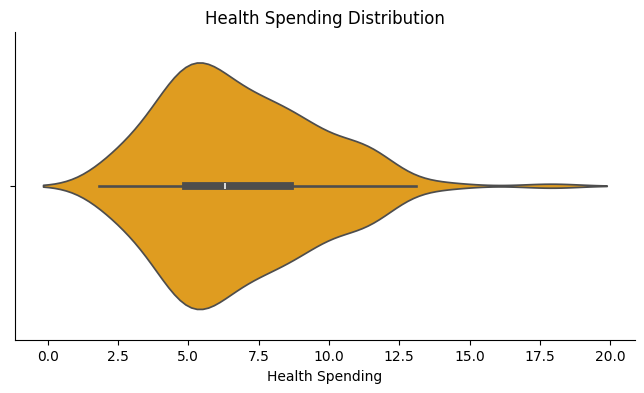

In [98]:
plt.figure(figsize=(8,4))
sns.violinplot(data=df, x='health', color='orange')
plt.title('Health Spending Distribution')
plt.xlabel('Health Spending')
sns.despine()
plt.show()

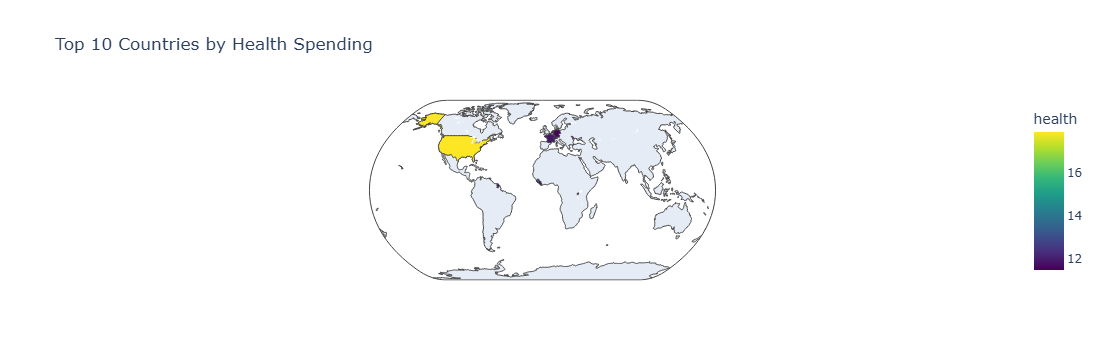

In [104]:
top10 = df.nlargest(10, 'health')

fig = px.choropleth(top10, locations='country', locationmode='country names',
                     color='health', color_continuous_scale='Viridis',
                     hover_name='country', projection='natural earth', title='Top 10 Countries by Health Spending')
fig.show()

In [108]:
top10[['country', 'health']]

,country,health
159,United States,17.9
101,"Micronesia, Fed. Sts.",14.2
132,Sierra Leone,13.1
54,France,11.9
110,Netherlands,11.9
88,Liberia,11.8
102,Moldova,11.7
26,Burundi,11.6
58,Germany,11.6
145,Switzerland,11.5


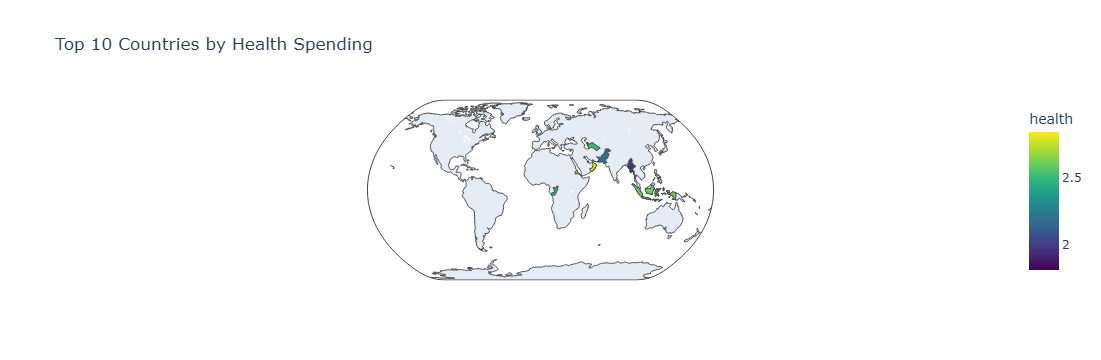

In [109]:
bottom10 = df.nsmallest(10, 'health')

fig = px.choropleth(bottom10, locations='country', locationmode='country names',
                     color='health', color_continuous_scale='Viridis',
                     hover_name='country', projection='natural earth', title='Top 10 Countries by Health Spending')
fig.show()

In [110]:
bottom10[['country', 'health']]

,country,health
123,Qatar,1.81
107,Myanmar,1.97
116,Pakistan,2.20
38,"Congo, Rep.",2.46
154,Turkmenistan,2.50
70,Indonesia,2.61
82,Kuwait,2.63
50,Eritrea,2.66
115,Oman,2.77
23,Brunei,2.84


### **d) Total Fertility and Child Mortality**

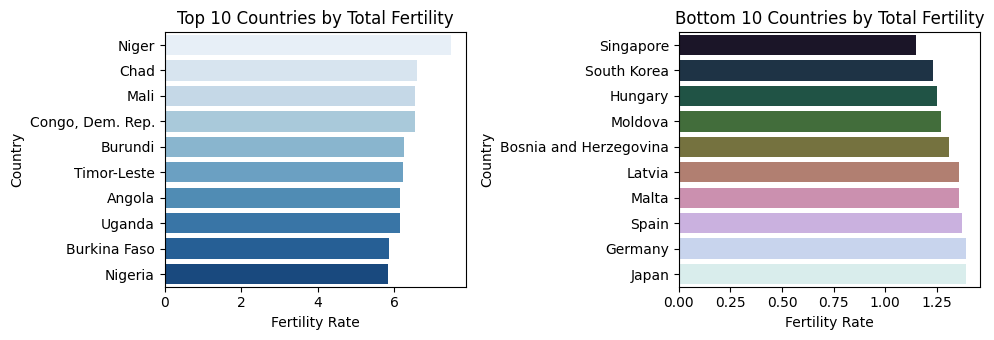

In [161]:
top10fer = df.nlargest(10, 'total_fer')
bottom10fer = df.nsmallest(10, 'total_fer')

fig, axes = plt.subplots(1, 2, figsize=(10,3.5))

sns.barplot(data=top10fer, y='country', x='total_fer', ci=None, palette='Blues', ax=axes[0])
axes[0].set_title('Top 10 Countries by Total Fertility')
axes[0].set_ylabel('Country')
axes[0].set_xlabel('Fertility Rate')

sns.barplot(data=bottom10fer, y='country', x='total_fer', ci=None, palette='cubehelix', ax=axes[1])
axes[1].set_title('Bottom 10 Countries by Total Fertility')
axes[1].set_ylabel('Country')
axes[1].set_xlabel('Fertility Rate')

plt.tight_layout()
plt.show()

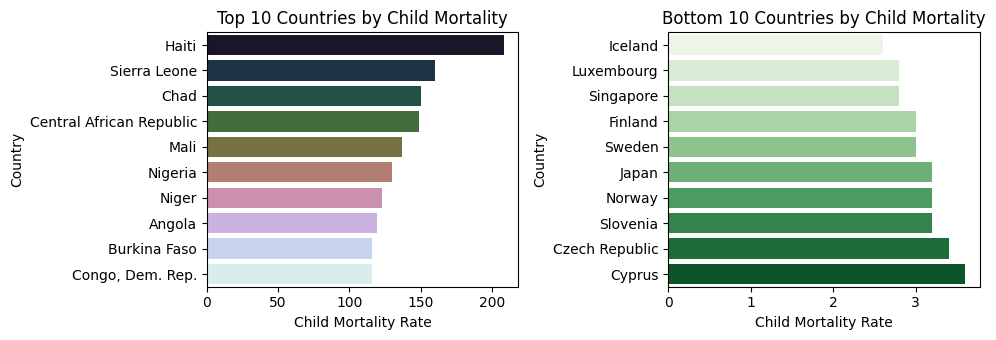

In [160]:
top10mor = df.nlargest(10, 'child_mort')
bottom10mor = df.nsmallest(10, 'child_mort')

fig, axes = plt.subplots(1, 2, figsize=(10,3.5))

sns.barplot(data=top10mor, y='country', x='child_mort', ci=None, palette='cubehelix', ax=axes[0])
axes[0].set_title('Top 10 Countries by Child Mortality')
axes[0].set_ylabel('Country')
axes[0].set_xlabel('Child Mortality Rate')

sns.barplot(data=bottom10mor, y='country', x='child_mort', ci=None, palette='Greens', ax=axes[1])
axes[1].set_title('Bottom 10 Countries by Child Mortality')
axes[1].set_ylabel('Country')
axes[1].set_xlabel('Child Mortality Rate')

plt.tight_layout()
plt.show()

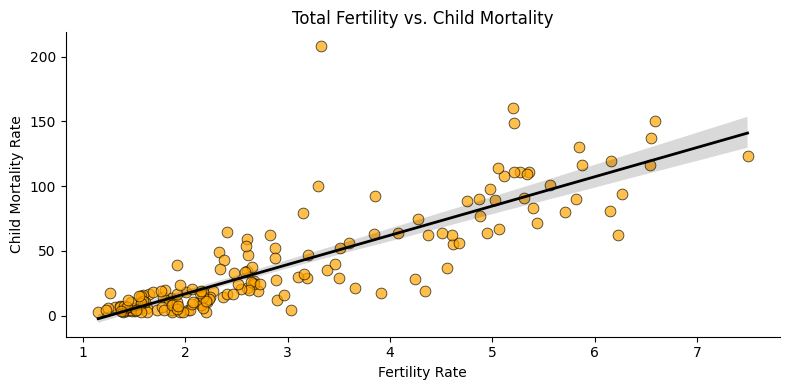

In [122]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='total_fer', y='child_mort', color='orange', s=60, edgecolor='k', alpha=0.7)
sns.regplot(data=df, x='total_fer', y='child_mort', scatter=False, line_kws={'color': 'black', 'linewidth': 2})
plt.title('Total Fertility vs. Child Mortality')
plt.xlabel('Fertility Rate')
plt.ylabel('Child Mortality Rate')
sns.despine()
plt.tight_layout()
plt.show()

### **c) Economic Indicators**

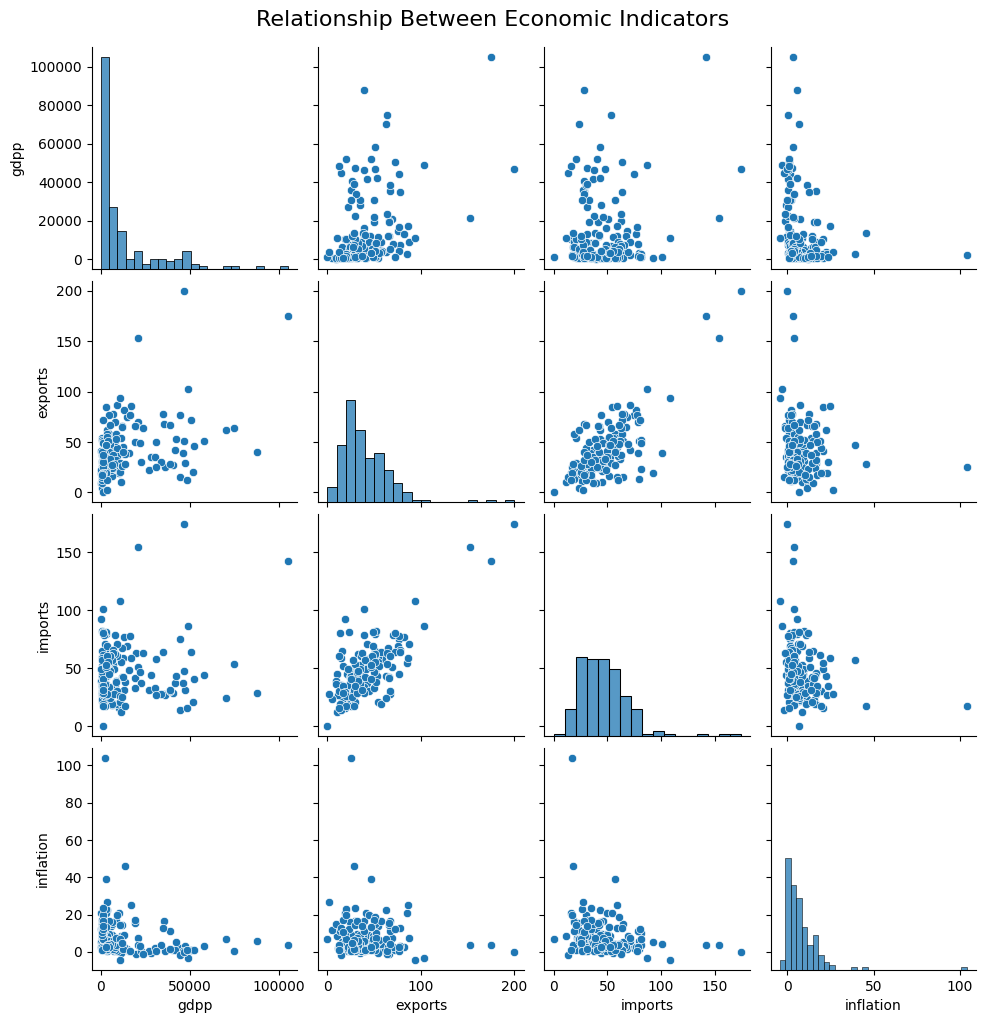

In [172]:
g = sns.pairplot(df[['gdpp', 'exports', 'imports', 'inflation']], kind='scatter')
g.fig.suptitle('Relationship Between Economic Indicators', y=1.02, fontsize=16)
plt.show()

### **e) Correlation Between All Features**

<AxesSubplot: >

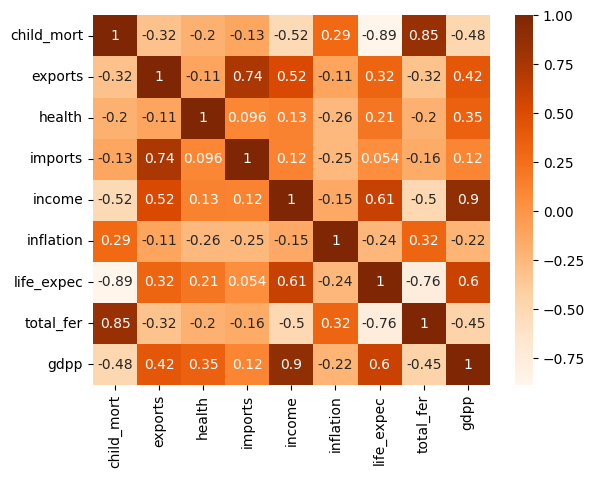

In [174]:
sns.heatmap(df.corr(), annot=True, cmap='Oranges')

### Conclusion of the Data Analysis:

The analysis shows that higher **child mortality** is linked to higher **total fertility**, indicating that families tend to have more children where child survival is less certain. Countries with higher **exports** also have higher **imports** and **income**, reflecting stronger economic activity. **GDP** and **income** are positively correlated with **life expectancy**, while lower **life expectancy** is associated with higher **child mortality** and **fertility rates**. Additionally, there is a slight trend where increased **income** corresponds to lower **total fertility** and **child mortality**, likely due to improved healthcare and living standards.